In [20]:
from calorine.calculators import CPUNEP
#import spglib
from ase.io import read, write
from ase.spacegroup import get_spacegroup
from ase.optimize import BFGS
from ase.filters import FrechetCellFilter
from ase.visualize import view
import matplotlib.pyplot as plt
import numpy as np
import os

In [18]:
cifs = ["mp-5020_BaTiO3.cif", "mp-5777_BaTiO3.cif", "mp-5986_BaTiO3.cif", "mp-2998_BaTiO3.cif"]

structures = []

for cif in cifs:
    structures.append(read(os.path.join("ROTC_structures", cif)))
    

In [21]:
write('ROTC_structures/structures.xyz', structures)

In [ ]:
cifs = ["mp-5020_BaTiO3.cif", "mp-5777_BaTiO3.cif", "mp-5986_BaTiO3.cif", "mp-2998_BaTiO3.cif"]

pre_relax_energies = []
energies = []
spacegroups = []
structures = []
for cif in cifs:
    atoms = read(os.path.join("ROTC_structures", cif))
    print("Pre-relax", atoms)

    spg = get_spacegroup(atoms)
    spacegroup = f"{spg.no} {spg.symbol}"
    print("Pre-relax", spacegroup)

    atoms.calc = CPUNEP("results/ALnep/iteration_2/nep.txt")
    E = atoms.get_potential_energy()
    pre_relax_energies.append(1e3*E/atoms.symbols.count("Ba"))
    spacegroups.append(spacegroup)

    cf = FrechetCellFilter(atoms)
    relax = BFGS(cf, logfile=None)
    relax.run(fmax=0.01)
    E = atoms.get_potential_energy()
    print("Post-relax", atoms)

    spg = get_spacegroup(atoms)
    spacegroup = f"{spg.no} {spg.symbol}"
    print("Post-relax", spacegroup)

    energies.append(1e3*E/atoms.symbols.count("Ba"))
    structures.append(atoms)
pre_relax_energies = np.array(pre_relax_energies)
pre_relax_energies -= pre_relax_energies.min()

energies = np.array(energies)
energies -= energies.min()

Pre-relax Atoms(symbols='Ba3Ti3O9', pbc=True, cell=[[5.75467227, 0.0, 0.0], [-2.877336134999999, 4.983692376273863, 0.0], [0.0, 0.0, 7.10998697]], spacegroup_kinds=...)
Pre-relax 160 R 3 m


/tmp/ipykernel_13128/1820477773.py:11: FutureWarning: `get_spacegroup` has been deprecated due to its misleading output. The returned `Spacegroup` object has symmetry operations for a standard setting regardress of the given `Atoms` object. See https://gitlab.com/ase/ase/-/issues/1534 for details. Please use `ase.spacegroup.symmetrize.check_symmetry` or `spglib` directly to get the symmetry operations for the given `Atoms` object.
  spg = get_spacegroup(atoms)


Post-relax Atoms(symbols='Ba3Ti3O9', pbc=True, cell=[[5.610264910210214, -1.022329472824971e-14, 4.143308652662112e-15], [-2.805132455105102, 4.858631934202306, 1.5085358511130794e-14], [3.592547520708948e-15, -1.5957879711536683e-14, 6.899886935950171]], spacegroup_kinds=..., calculator=CPUNEP(...))
Post-relax 160 R 3 m
Pre-relax Atoms(symbols='Ba2Ti2O6', pbc=True, cell=[5.805608, 5.855292, 3.987531], spacegroup_kinds=...)
Pre-relax 38 A m m 2


/tmp/ipykernel_13128/1820477773.py:26: FutureWarning: `get_spacegroup` has been deprecated due to its misleading output. The returned `Spacegroup` object has symmetry operations for a standard setting regardress of the given `Atoms` object. See https://gitlab.com/ase/ase/-/issues/1534 for details. Please use `ase.spacegroup.symmetrize.check_symmetry` or `spglib` directly to get the symmetry operations for the given `Atoms` object.
  spg = get_spacegroup(atoms)


Post-relax Atoms(symbols='Ba2Ti2O6', pbc=True, cell=[[5.6196473962399045, 6.617874349536254e-17, -7.514386280977366e-18], [-3.4551611327730163e-16, 5.644952501139486, 1.3634405452769717e-14], [6.296948388699329e-17, 6.014983180146575e-15, 3.9469507451185692]], spacegroup_kinds=..., calculator=CPUNEP(...))
Post-relax 38 A m m 2
Pre-relax Atoms(symbols='BaTiO3', pbc=True, cell=[4.004457, 4.004457, 4.200636], spacegroup_kinds=...)
Pre-relax 99 P 4 m m
Post-relax Atoms(symbols='BaTiO3', pbc=True, cell=[[3.949792765461301, 1.4280371989910039e-18, -3.844715249171564e-17], [8.048312595745041e-17, 3.949792765461326, -4.995653369714615e-15], [-1.1765568330675189e-16, 3.454014286635458e-15, 3.9992923672658804]], spacegroup_kinds=..., calculator=CPUNEP(...))
Post-relax 99 P 4 m m
Pre-relax Atoms(symbols='BaTiO3', pbc=True, cell=[4.035583, 4.035583, 4.035583], spacegroup_kinds=...)
Pre-relax 221 P m -3 m
Post-relax Atoms(symbols='BaTiO3', pbc=True, cell=[[3.957253206884298, 3.696980180255224e-18, 

Text(0, 0.5, 'Relative energies (meV/f.u.)')

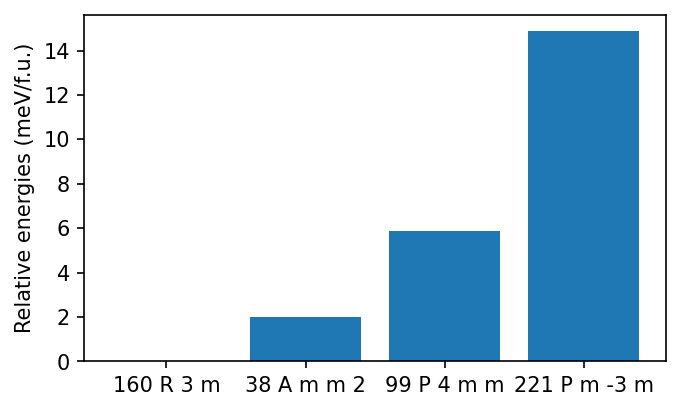

In [16]:
fig, ax = plt.subplots(figsize=(5, 3), dpi=150)
ax.bar(spacegroups, energies)
#ax.bar(spacegroups, pre_relax_energies)
ax.set_ylabel("Relative energies (meV/f.u.)")

In [ ]:
view(structures)

<Popen: returncode: None args: ['/home/tbrav/projects/OxideSlabs2/.venv/bin/...>

Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/matplotlib_inline/backend_inline.py", line 90, in show
    display(
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/IPython/core/display_functions.py", line 265, in

In [139]:
from calorine.tools import get_force_constants, relax_structure
from pandas import DataFrame
from phonopy.physical_units import get_physical_units
from seekpath import get_explicit_k_path
units = get_physical_units()

In [153]:
atoms = structures[0]
phonon = get_force_constants(atoms, CPUNEP("nep.txt"), [4, 4, 4])

In [154]:
structure_tuple = (atoms.cell, atoms.get_scaled_positions(), atoms.numbers)
path = get_explicit_k_path(structure_tuple)

/Users/work/miniconda3/envs/dft-stuff/lib/python3.13/site-packages/seekpath/hpkot/__init__.py:172: DeprecationWarning: dict interface is deprecated. Use attribute interface instead
  conv_lattice = dataset["std_lattice"]


In [155]:
phonon.run_band_structure([path['explicit_kpoints_rel']])
band = phonon.get_band_structure_dict()

In [156]:
df = DataFrame(band['frequencies'][0])
df.index = path['explicit_kpoints_linearcoord']

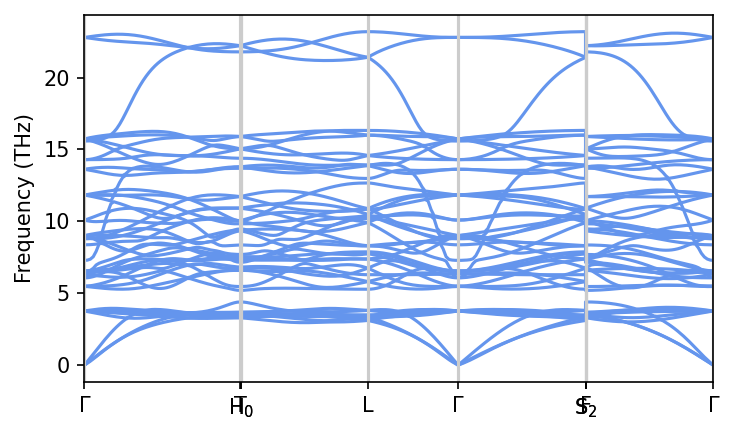

In [157]:
fig, ax = plt.subplots(figsize=(5, 3), dpi=150)

for col in df.columns:
    ax.plot(df.index, df[col], color='cornflowerblue')
ax.set_xlim(df.index.min(), df.index.max())

ax.set_ylabel('Frequency (THz)')

# beautify the labels on the x-axis
labels = path['explicit_kpoints_labels']
labels = [r'$\Gamma$' if m == 'GAMMA' else m for m in labels]
labels = [m.replace('_', '$_') + '$' if '_' in m else m for m in labels]
df_path = DataFrame(dict(labels=labels,
                         positions=path['explicit_kpoints_linearcoord']))
df_path.drop(df_path.index[df_path.labels == ''], axis=0, inplace=True)
ax.set_xticks(df_path.positions)
ax.set_xticklabels(df_path.labels)
for xp in df_path.positions:
    ax.axvline(xp, color='0.8')

plt.tight_layout()